# Wasted Wind - 2025 UK Wind Farm Curtailment

## Project Overview

This project explores publicly available data that outlines transactions between the National Energy System Operator (NESO) and UK-based windfarm operators, specifically reductions in wind generation that occur as a result of system constraints (wind curtailments).

### Key Questions

- Where do wind curtailments generally occur in the UK?
- How much energy is curtailed and how much does it cost to curtail this energy?

### Data Sources

- Elexon Insights BMRS API for bidding and pricing data and for basic BMU metadata
- Power Station Dictionary for BMU location data

### Methods

- Requested all relevant data for 2025 and performed SQL queries to process and combine data to calculate total expected and annual energy usage, and the cost of this to the system operator.
- Combined with location data from Power Station Dictionary
- Visualised data using Flourish

### Key Findings

- £375 million was spent paying windfarms to reduce their wind generation from their expected output
- A total of 10.9 TWh was curtailed
- Almost all curtailment occurs in Scotland north of the B6 boundary, highlighting the bottleneck that this poses

### 1. Data Acquisition

The most important data to answer the question of wind curtailment is **"Bid-Offer-Accepted-Level-Flagged" (BOALF) data**, which contains accepted bid-offer data in instances where revised bids are given by NESO when they realise they cannot meet their previous agreements, for example due to system constraints. 

This data is according to the respective Balancing Mechanism Unit (BMU), for which metadata exists in the **BMUnits** dataset.

The expected output of a given BMU is provided as the Final Physical Notification (FPN), which can be obtained via the **Physical Notification (PN)** dataset. 

The price per MW of any change in output relative to the FPN is given in the **"Bid-Order-Data" (BOD)** dataset.

Finally, the location data of many (but not all) BMUs can be obtained from the dictionary files available in **Power Station Dictionary**

Some of the API datasets allow for collecting all data for a given year at once, while some require collecting them monthly.

In [1]:
import requests
import pandas as pd
import csv
import duckdb
import datetime
from pathlib import Path
from dateutil.relativedelta import relativedelta
import itertools
import json


start_date = '2025-01-01T00:00Z'
end_date = '2026-01-01T00:00Z'

params = {
    'from': start_date,
    'to': end_date
}

# Fetch Bid-Offer-Acceptance-Flagged (BOALF) data

if not Path('data/bid_data.json').exists():
    print("Fetching BOALF data...")
    response = requests.get('https://data.elexon.co.uk/bmrs/api/v1/datasets/BOALF/stream', params=params)
    with open('data/bid_data.json', 'w') as f:
        f.write(response.text)
else:
    print("BOALF data already exists, skipping")

# Fetch Balancing Mechanism Unit (BMU) data

if not Path('data/bmu_data.json').exists():
    print("Fetching BMU data...")
    response = requests.get('https://data.elexon.co.uk/bmrs/api/v1/reference/bmunits/all')
    with open('data/bmu_data.json', 'w') as f:
        f.write(response.text)
else:
    print("BMU data already exists, skipping")

# Fetch Physical Notification (PN) data

if not Path('data/pn_data.json').exists():
    print('Fetching PN data...')

    start = datetime.date(2025,1,1)
    end = datetime.date(2026,1,1)
    all_pn = []

    while start < end:
        start_date = start
        end_date = start + relativedelta(months=1)
        params = {
        'from': start_date.strftime('%Y-%m-%dT%H:%MZ'),
        'to': end_date.strftime('%Y-%m-%dT%H:%MZ')
        }
        response = requests.get(
        'https://data.elexon.co.uk/bmrs/api/v1/datasets/PN/stream',
        params = params
        )
        print(f"Fetched {start.strftime('%Y-%m')}: {response.status_code}")
        all_pn.append(response.json())
        start = end_date

    flat = list(itertools.chain.from_iterable(all_pn))
    with open('data/pn_data.json', 'w') as f:
        json.dump(flat, f)

else:
    print('PN data found, skipping')

# Fetch Bid-Offer price (BOD) data

if not Path('data/price_data.json').exists():
    print('Fetching Price data...')

    start = datetime.date(2025,1,1)
    end = datetime.date(2026,1,1)

    all_prices = []

    while start < end:
        start_date = start
        end_date = start + relativedelta(months=1)
        params = {
        'from': start_date.strftime('%Y-%m-%dT%H:%MZ'),
        'to': end_date.strftime('%Y-%m-%dT%H:%MZ')
        }
        response = requests.get(
        'https://data.elexon.co.uk/bmrs/api/v1/datasets/BOD/stream',
        params = params
        )
        print(f"Fetched {start.strftime('%Y-%m')}: {response.status_code}")
        all_prices.append(response.json())
        start = end_date

    flat = list(itertools.chain.from_iterable(all_prices))
    with open('data/price_data.json', 'w') as f:
        json.dump(flat, f)
else:
    print('Price data found, skipping')

BOALF data already exists, skipping
BMU data already exists, skipping
PN data found, skipping
Price data found, skipping


### 2. Data Exploration
We can use DuckDB moving forward to work easily with the large datasets.

First we can look through each dataset to get a better understanding of them, beginning with the fuel types in the BMU data:

In [2]:
con = duckdb.connect()

con.sql("""
        SELECT fuelType, COUNT(*) FROM 'data/bmu_data.json' GROUP BY fuelType
        """).show()

┌──────────┬──────────────┐
│ fuelType │ count_star() │
│ varchar  │    int64     │
├──────────┼──────────────┤
│ CCGT     │           65 │
│ NPSHYD   │           36 │
│ COAL     │           10 │
│ WIND     │          257 │
│ INTNEM   │            1 │
│ NULL     │         2374 │
│ INTELEC  │            2 │
│ INTEW    │            1 │
│ BIOMASS  │           18 │
│ INTGRNL  │            2 │
│ INTNED   │            1 │
│ INTFR    │            1 │
│ INTIFA2  │            1 │
│ OTHER    │           66 │
│ PS       │           16 │
│ INTNSL   │            1 │
│ OCGT     │           23 │
│ NUCLEAR  │           16 │
│ INTIRL   │            1 │
│ INTVKL   │            2 │
├──────────┴──────────────┤
│ 20 rows       2 columns │
└─────────────────────────┘



It's possible that the NULL category contains more windfarms, but these will have to be ignored for now.

Next, we can look at the BOALF data:

In [3]:
con.sql("""
        SELECT * FROM 'data/bid_data.json' LIMIT 10
        """).show()

┌─────────┬────────────────┬──────────────────────┬────────────────────┬─────────────────────┬─────────────────────┬───────────┬─────────┬──────────────────┬─────────────────────┬──────────────┬─────────┬───────────────┬──────────┬─────────┬────────────────────┬───────────┐
│ dataset │ settlementDate │ settlementPeriodFrom │ settlementPeriodTo │      timeFrom       │       timeTo        │ levelFrom │ levelTo │ acceptanceNumber │   acceptanceTime    │ deemedBoFlag │ soFlag  │ amendmentFlag │ storFlag │ rrFlag  │ nationalGridBmUnit │  bmUnit   │
│ varchar │      date      │        int64         │       int64        │      timestamp      │      timestamp      │   int64   │  int64  │      int64       │      timestamp      │   boolean    │ boolean │    varchar    │ boolean  │ boolean │      varchar       │  varchar  │
├─────────┼────────────────┼──────────────────────┼────────────────────┼─────────────────────┼─────────────────────┼───────────┼─────────┼──────────────────┼──────────────────

While there are "Settlement Periods" which are 30-minute increments, the BOALF data spans any number of minutes and across settlements periods, so this will need to be handled carefully. Also, the system operator often can accept multiple offers for a given time period, updating as time goes on. This will mean multiple acceptance numbers for a given time period, where previous acceptance numbers need to be filtered out.

Next, the BOD pricing data:

In [4]:
con.sql("""
        SELECT * FROM 'data/price_data.json' LIMIT 10
        """).show()

┌─────────┬────────────────┬──────────────────┬─────────────────────┬───────────┬─────────────────────┬─────────┬────────┬────────┬────────┬────────────────────┬────────────┐
│ dataset │ settlementDate │ settlementPeriod │      timeFrom       │ levelFrom │       timeTo        │ levelTo │ pairId │ offer  │  bid   │ nationalGridBmUnit │   bmUnit   │
│ varchar │      date      │      int64       │      timestamp      │   int64   │      timestamp      │  int64  │ int64  │ double │ double │      varchar       │  varchar   │
├─────────┼────────────────┼──────────────────┼─────────────────────┼───────────┼─────────────────────┼─────────┼────────┼────────┼────────┼────────────────────┼────────────┤
│ BOD     │ 2025-02-01     │                1 │ 2025-02-01 00:00:00 │       -16 │ 2025-02-01 00:30:00 │     -16 │     -1 │  179.0 │   85.0 │ ABERU-1            │ E_ABERDARE │
│ BOD     │ 2025-02-01     │                1 │ 2025-02-01 00:00:00 │        16 │ 2025-02-01 00:30:00 │      16 │      1 │  1

In [5]:
con.sql("""
        SELECT * FROM 'data/pn_data.json' ORDER BY settlementDate LIMIT 10
        """).show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────┬────────────────┬──────────────────┬─────────────────────┬─────────────────────┬───────────┬─────────┬────────────────────┬─────────────┐
│ dataset │ settlementDate │ settlementPeriod │      timeFrom       │       timeTo        │ levelFrom │ levelTo │ nationalGridBmUnit │   bmUnit    │
│ varchar │      date      │      int64       │      timestamp      │      timestamp      │   int64   │  int64  │      varchar       │   varchar   │
├─────────┼────────────────┼──────────────────┼─────────────────────┼─────────────────────┼───────────┼─────────┼────────────────────┼─────────────┤
│ PN      │ 2024-12-31     │               48 │ 2024-12-31 23:59:00 │ 2025-01-01 00:00:00 │        -2 │       0 │ AG-COCT00          │ 2__CMRCY001 │
│ PN      │ 2024-12-31     │               48 │ 2024-12-31 23:59:00 │ 2025-01-01 00:00:00 │        -1 │      -4 │ WTRSB-1            │ 2__GCMRO002 │
│ PN      │ 2024-12-31     │               48 │ 2024-12-31 23:59:00 │ 2025-01-01 00:00:00 │         0 │   

This data follows settlements periods, but the pairId, levelFrom, and levelTo require more attention. Each BM Unit provides up to 5 bands above the Operating Baseline (represented by PN) and 5 below, with bids, offers, and MW level thresholds for each of these. Since we are only looking at curtailments, we can filter for pairId < 0. When we come to calculating the actual costs, we will need to be mindful of the final cost spanning multiple bands.

### 3. Data Analysis

The first steps are to:

- Filter for soFlag = True (flagged as a system constraint) and fuelType = 'WIND'
- Filter for the most recent acceptance a given time period in the BOALF data
- Create a transaction table that joins on the Physical Notification (PN) data to each BOALF row, giving the expected vs. actual power generation

For PN data, an ASOF join is used as the time periods will not exactly line up. The PN data typically does not fluctuate significantly in short time periods, so this is a reasonable approximation

In [35]:
con.sql("""
    CREATE OR REPLACE VIEW latest_acceptances AS (
        SELECT *
        FROM (
            SELECT *,
                ROW_NUMBER() OVER (
                    PARTITION BY nationalGridBmUnit, timeFrom
                    ORDER BY acceptanceNumber DESC
                ) AS rn
            FROM 'data/bid_data.json'
        )
        WHERE rn = 1
    );

    CREATE OR REPLACE VIEW transactions AS (
        SELECT
            pn.settlementDate,
            pn.settlementPeriod AS pn_setPeriod,
            pn.timeFrom AS pn_timeFrom,
            pn.timeTo AS pn_timeTo,
            bids.timeFrom AS boalf_timeFrom,
            bids.timeTo AS boalf_timeTo,
            bids.levelFrom AS boalf_levelFrom,
            bids.levelTo AS boalf_levelTo,
            (CASE WHEN fuel.fuelType = 'WIND' THEN 'Wind curtailed' ELSE 'Gas ramped up' END) as action,
            pn.nationalGridBmUnit,
            fuel.fuelType,
            bids.settlementPeriodFrom AS boalf_setFrom,
            bids.settlementPeriodTo AS boalf_setTo,
            pn.levelFrom AS pn_levelFrom,
            pn.levelTo AS pn_levelTo,
            date_part('epoch', LEAST(pn.timeTo,bids.timeTo) - GREATEST(pn.timeFrom,bids.timeFrom)) / 60.0 AS boalf_mins,
            date_part('epoch', pn.timeTo - pn.timeFrom) / 60.0 as pn_mins
        FROM 'data/pn_data.json' AS pn
        LEFT JOIN 'data/bmu_data.json' AS fuel
            ON pn.nationalGridBmUnit = fuel.nationalGridBmUnit
        LEFT JOIN (SELECT * FROM latest_acceptances WHERE soFlag = TRUE) AS bids
            ON pn.nationalGridBmUnit = bids.nationalGridBmUnit
            AND pn.settlementDate = bids.settlementDate
            AND pn.settlementPeriod <= bids.settlementPeriodTo
            AND pn.settlementPeriod >= bids.settlementPeriodFrom
        WHERE fuel.fuelType in ('WIND','CCGT', 'OCGT') AND boalf_mins > 0
        ORDER BY pn.timeFrom
    );
        

""")

In [7]:
con.sql("""
        SELECT * FROM transactions WHERE boalf_setTo - boalf_setFrom > 1  AND nationalGridBmUnit = 'VKNGW-1' ORDER BY settlementDate,pn_setPeriod
        """)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌────────────────┬──────────────┬─────────────────────┬─────────────────────┬─────────────────────┬─────────────────────┬─────────────────┬───────────────┬────────────────┬────────────────────┬──────────┬───────────────┬─────────────┬──────────────┬────────────┬────────────┬─────────┐
│ settlementDate │ pn_setPeriod │     pn_timeFrom     │      pn_timeTo      │   boalf_timeFrom    │    boalf_timeTo     │ boalf_levelFrom │ boalf_levelTo │     action     │ nationalGridBmUnit │ fuelType │ boalf_setFrom │ boalf_setTo │ pn_levelFrom │ pn_levelTo │ boalf_mins │ pn_mins │
│      date      │    int64     │      timestamp      │      timestamp      │      timestamp      │      timestamp      │      int64      │     int64     │    varchar     │      varchar       │ varchar  │     int64     │    int64    │    int64     │   int64    │   double   │ double  │
├────────────────┼──────────────┼─────────────────────┼─────────────────────┼─────────────────────┼─────────────────────┼─────────────────┼───

With the transactions table created, we can calculate energy from the power data using the elapsed_mins, both according to the BOALF and PN data, with the difference between them being the curtailed energy amount:

In [36]:
con.sql("""
        CREATE OR REPLACE VIEW energy_table AS (
        SELECT
                action,
                nationalGridBmUnit,
                settlementDate,
                pn_setPeriod,
                boalf_setFrom,
                boalf_setTo,
                pn_timeFrom,
                pn_timeTo,
                boalf_timeFrom,
                boalf_timeTo,
                boalf_levelFrom,
                boalf_levelTo,
                (boalf_levelFrom + boalf_levelTo) / 2.0 as boalf_level,
                (PN_levelFrom+pn_levelTo) / 2.0 as pn_level,
                boalf_mins,
                pn_mins,
                ((boalf_levelFrom + boalf_levelTo) / 2) * (boalf_mins / 60.0) as BOALF_mwh,
                ((PN_levelFrom+pn_levelTo) / 2.0) * (boalf_mins / 60.0) as PN_mwh,
                ((PN_levelFrom+pn_levelTo) / 2.0) * (boalf_mins / 60.0) - (((boalf_levelFrom + boalf_levelTo) / 2.0) * boalf_mins / 60.0) as action_mwh
        FROM transactions
        WHERE (action = 'Wind curtailed' AND (boalf_levelFrom + boalf_levelTo) / 2.0 < ((PN_levelFrom+pn_levelTo) / 2.0)) OR (action = 'Gas ramped up' AND (boalf_levelFrom + boalf_levelTo) / 2.0 > ((PN_levelFrom+pn_levelTo) / 2.0) AND (settlementDate, pn_setPeriod) IN (
           SELECT settlementDate, pn_setPeriod 
           FROM transactions 
           WHERE action = 'Wind curtailed'
             AND (boalf_levelFrom + boalf_levelTo) / 2.0 < (PN_levelFrom + pn_levelTo) / 2.0
       ))
        ORDER BY BOALF_timeFrom
        )
        """)


In [9]:
con.sql("""
        SELECT * FROM energy_table WHERE boalf_setTo-boalf_setFrom > 1 ORDER BY settlementDate,pn_setPeriod
        """)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌────────────────┬────────────────────┬────────────────┬──────────────┬───────────────┬─────────────┬─────────────────────┬─────────────────────┬─────────────────────┬─────────────────────┬─────────────────┬───────────────┬─────────────┬──────────┬────────────┬─────────┬─────────────────────┬─────────────────────┬─────────────────────┐
│     action     │ nationalGridBmUnit │ settlementDate │ pn_setPeriod │ boalf_setFrom │ boalf_setTo │     pn_timeFrom     │      pn_timeTo      │   boalf_timeFrom    │    boalf_timeTo     │ boalf_levelFrom │ boalf_levelTo │ boalf_level │ pn_level │ boalf_mins │ pn_mins │      BOALF_mwh      │       PN_mwh        │     action_mwh      │
│    varchar     │      varchar       │      date      │    int64     │     int64     │    int64    │      timestamp      │      timestamp      │      timestamp      │      timestamp      │      int64      │     int64     │   double    │  double  │   double   │ double  │       double        │       double        │       do

The BOALF and PN power levels can be used to calculate the curtailment cost using the price bands given in the BOD data, ensuring that the amount charged is according to the amount of energy generated within that band alone:

In [10]:
con.sql("""
        CREATE OR REPLACE VIEW cprice AS (
        SELECT
                *,
                COALESCE((SUM(levelFrom) OVER (
                        PARTITION BY nationalGridBmUnit, settlementDate, settlementPeriod, (CASE WHEN pairId < 0 THEN 'negative' ELSE 'positive' END)
                        ORDER BY ABS(pairId)
                        ROWS BETWEEN UNBOUNDED PRECEDING AND 1 PRECEDING
                )),0) AS previous_bands_total
        FROM 'data/price_data.json' as cprice
        )
        """)

In [11]:
con.sql("""
        SELECT * FROM energy_table
        """)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌────────────────┬────────────────────┬────────────────┬──────────────┬───────────────┬─────────────┬─────────────────────┬─────────────────────┬─────────────────────┬─────────────────────┬─────────────────┬───────────────┬─────────────┬──────────┬────────────┬─────────┬────────────────────┬────────────────────┬─────────────────────┐
│     action     │ nationalGridBmUnit │ settlementDate │ pn_setPeriod │ boalf_setFrom │ boalf_setTo │     pn_timeFrom     │      pn_timeTo      │   boalf_timeFrom    │    boalf_timeTo     │ boalf_levelFrom │ boalf_levelTo │ boalf_level │ pn_level │ boalf_mins │ pn_mins │     BOALF_mwh      │       PN_mwh       │     action_mwh      │
│    varchar     │      varchar       │      date      │    int64     │     int64     │    int64    │      timestamp      │      timestamp      │      timestamp      │      timestamp      │      int64      │     int64     │   double    │  double  │   double   │ double  │       double       │       double       │       double  

In [12]:
con.sql("""
        CREATE OR REPLACE VIEW et_prices AS (
        SELECT
                *,
                ABS(CASE WHEN action = 'Wind curtailed' AND pairId < 0 AND boalf_level < pn_level THEN
                        (CASE WHEN (level_difference - previous_bands_total) < 0 AND (level_difference - previous_bands_total - price_band) <= 0 THEN price_band * bid * boalf_mins/60
                                WHEN (level_difference - previous_bands_total) < 0 AND (level_difference - previous_bands_total - price_band) > 0 THEN (level_difference - previous_bands_total) * bid * boalf_mins / 60
                                END)
        
                        WHEN action = 'Gas ramped up' AND pairId > 0 AND boalf_level > pn_level THEN
                                (CASE WHEN (level_difference - previous_bands_total) > 0 AND (level_difference - previous_bands_total - price_band) >= 0 THEN price_band * offer * boalf_mins / 60
                                        WHEN (level_difference - previous_bands_total) > 0 AND (level_difference - previous_bands_total - price_band) < 0 THEN (level_difference - previous_bands_total) * offer * boalf_mins / 60
                                        END)
                        ELSE 0 END) as action_cost
        FROM
        (SELECT
                action,
                et.nationalGridBmUnit,
                et.settlementDate,
                pn_setPeriod,
                pn_timeFrom,
                pn_timeTo,
                boalf_timeFrom,
                boalf_timeTo,
                boalf_levelFrom,
                boalf_levelTo,
                boalf_level,
                pn_level,
                boalf_level - pn_level as level_difference,
                boalf_mins,
                boalf_mwh,
                pn_mwh,
                action_mwh,
                pairId,
                (cprice.levelFrom) as price_band,
                previous_bands_total,
                offer,
                bid
        FROM energy_table as et
        LEFT JOIN cprice
        ON et.nationalGridBmUnit = cprice.nationalGridBmUnit AND cprice.settlementDate = et.settlementDate AND cprice.settlementPeriod = et.pn_setPeriod
        WHERE (action = 'Wind curtailed' AND pairId < 0 AND boalf_level < pn_level) OR (action = 'Gas ramped up' AND pairId > 0 AND boalf_level > pn_level)
        ));
        """)

In [ ]:
con.sql("""
        CREATE OR REPLACE VIEW et_priced AS(
        SELECT
                action,
                nationalGridBmUnit,
                settlementDate,
                pn_setPeriod,
                SUM(action_cost) as action_cost
        FROM et_prices
        GROUP BY action, nationalGridBmUnit, settlementDate, pn_setPeriod
        );
        """)

Ultimately, we will need to bin the readings to a consistent time grid to be able to track both the expected generation (PN data, according to settlementPeriod) and actual generation (arbitrary times). Since we are looking across a year, we can simply summarise daily:

In [14]:
con.sql("""
        -- 1. Aggregate cost from priced table (after BOD join)
CREATE OR REPLACE VIEW setperiod_cost AS (
    SELECT
        action,
        nationalGridBmUnit,
        settlementDate,
        pn_setPeriod as settlementPeriod,
        SUM(action_cost) as action_cost
    FROM et_prices
    GROUP BY action, nationalGridBmUnit, settlementDate, pn_setPeriod
);

-- 2. Aggregate energy from energy_table (before BOD join, no duplication)
CREATE OR REPLACE VIEW setperiod_energy AS (
    SELECT
        action,
        nationalGridBmUnit,
        settlementDate,
        pn_setPeriod as settlementPeriod,
        SUM(action_mwh) as action_mwh
    FROM energy_table
    GROUP BY action, nationalGridBmUnit, settlementDate, pn_setPeriod
);

-- 3. Expected MWh fresh from raw PN data
CREATE OR REPLACE VIEW setperiod_pn AS (
    SELECT
        (CASE WHEN fuel.fuelType = 'WIND' THEN 'Wind curtailed' ELSE 'Gas ramped up' END) as action,
        pn.nationalGridBmUnit,
        pn.settlementDate,
        pn.settlementPeriod,
        MIN(pn.timeFrom) as timeFrom,
        MAX(pn.timeTo) as timeTo,
        SUM((pn.levelFrom + pn.levelTo) / 2.0 * date_part('epoch', pn.timeTo - pn.timeFrom) / 3600.0) AS expected_mwh
    FROM 'data/pn_data.json' pn
    JOIN 'data/bmu_data.json' fuel
        ON pn.nationalGridBmUnit = fuel.nationalGridBmUnit
    WHERE fuel.fuelType IN ('WIND', 'CCGT', 'OCGT')
    GROUP BY (CASE WHEN fuel.fuelType = 'WIND' THEN 'Wind curtailed' ELSE 'Gas ramped up' END), pn.nationalGridBmUnit, pn.settlementDate, pn.settlementPeriod
);

-- 4. Join everything one-to-one
CREATE OR REPLACE VIEW setperiod_data AS (
    SELECT
        p.action,
        p.nationalGridBmUnit,
        p.settlementDate,
        p.settlementPeriod,
        p.timeFrom,
        p.timeTo,
        p.expected_mwh,
        COALESCE(e.action_mwh, 0) as action_mwh,
        p.expected_mwh - COALESCE(e.action_mwh, 0) as actual_mwh,
        COALESCE(c.action_cost, 0) as action_cost
    FROM setperiod_pn p
    LEFT JOIN setperiod_energy e
        ON p.nationalGridBmUnit = e.nationalGridBmUnit
        AND p.settlementDate = e.settlementDate
        AND p.settlementPeriod = e.settlementPeriod
    LEFT JOIN setperiod_cost c
        ON e.action = c.action
        AND e.nationalGridBmUnit = c.nationalGridBmUnit
        AND e.settlementDate = c.settlementDate
        AND e.settlementPeriod = c.settlementPeriod
        );
        """)


In [15]:
con.sql("""
        SELECT * FROM setperiod_data WHERE action = 'Wind curtailed' ORDER BY action_mwh
        """)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌────────────────┬────────────────────┬────────────────┬──────────────────┬─────────────────────┬─────────────────────┬────────────────────┬────────────┬────────────────────┬─────────────┐
│     action     │ nationalGridBmUnit │ settlementDate │ settlementPeriod │      timeFrom       │       timeTo        │    expected_mwh    │ action_mwh │     actual_mwh     │ action_cost │
│    varchar     │      varchar       │      date      │      int64       │      timestamp      │      timestamp      │       double       │   double   │       double       │   double    │
├────────────────┼────────────────────┼────────────────┼──────────────────┼─────────────────────┼─────────────────────┼────────────────────┼────────────┼────────────────────┼─────────────┤
│ Wind curtailed │ LNCSO-1            │ 2025-01-25     │               44 │ 2025-01-25 21:30:00 │ 2025-01-25 22:00:00 │              19.75 │        0.0 │              19.75 │         0.0 │
│ Wind curtailed │ BTUIW-3            │ 2025-01-25     

In [37]:
con.sql("""
        SELECT
            action,
            SUM(expected_mwh),
            SUM(actual_mwh),
            SUM(action_mwh),
            SUM(action_cost)
        FROM setperiod_data
        GROUP BY action
        """)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌────────────────┬───────────────────┬───────────────────┬─────────────────────┬───────────────────┐
│     action     │ sum(expected_mwh) │  sum(actual_mwh)  │   sum(action_mwh)   │ sum(action_cost)  │
│    varchar     │      double       │      double       │       double        │      double       │
├────────────────┼───────────────────┼───────────────────┼─────────────────────┼───────────────────┤
│ Gas ramped up  │ 67391651.72500128 │ 71475092.45000157 │ -4083440.7250000043 │ 557157810.4854171 │
│ Wind curtailed │  78848669.4166654 │ 68540463.33333269 │  10308206.083333347 │ 399947734.2648339 │
└────────────────┴───────────────────┴───────────────────┴─────────────────────┴───────────────────┘

Now we can do the same with the PN data and combine the two:

This gives a very useful table of expected/actual energy generation per BMU per day. We can now combine this with location data from Power Station Dictionary, format values, and export to a .csv:

In [17]:
con.sql("""
        CREATE OR REPLACE VIEW bmu_dict AS (SELECT TRIM(UNNEST(STRING_SPLIT(ngc_bmu_id, ','))) AS single_bmu_id,
             *
               FROM read_csv('data/ids.csv', ignore_errors=true));
        
        SELECT
                action,
                bmu.fuelType,
                bmu.leadPartyName,
                bmu.gspGroupId,
                bmu.demandCapacity,
                bmu.generationCapacity,
                d.nationalGridBmUnit as BmUnitId,
                settlementDate,
                settlementPeriod,
                timeFrom,
                timeTo,
                expected_mwh as "expected_mwh",
                actual_mwh as "actual_mwh",
                ABS(actual_mwh - expected_mwh) as "change_in_mwh",
                action_cost as "change_cost",
                COALESCE(longitude,0) as longitude,
                COALESCE(latitude,0) as latitude
        FROM setperiod_data as d
        LEFT JOIN 'data/bmu_data.json' as bmu
        ON bmu.nationalGridBmUnit = d.nationalGridBmUnit
        LEFT JOIN bmu_dict
        ON bmu_dict.single_bmu_id = d.nationalGridBmUnit
        LEFT JOIN 'data/plant-locations.csv' as loc
        ON bmu_dict.dictionary_id = loc.dictionary_id
        WHERE settlementDate >= '2025-01-01' AND settlementDate < '2026-01-01'
        ORDER BY settlementDate, settlementPeriod, d.nationalGridBmUnit
        """).to_csv('data/time_data.csv')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [18]:
con.sql("""
        SELECT * FROM 'data/bmu_data.json'
        """)

┌────────────────────┬──────────────┬──────────────────┬──────────┬───────────────────────────────┬────────────┬─────────┬────────────────────────────┬─────────────┬────────────────┬────────────────────┬─────────────────────────────┬────────────────────────┬────────────────────────────────────────────┬───────────────────────────────────────────────┬────────────────────────────────────────────┬───────────────────────────────────────────────┬────────────────────────┬────────────────────────┬────────────┬───────────────────────┬──────────────────┐
│ nationalGridBmUnit │ elexonBmUnit │       eic        │ fuelType │         leadPartyName         │ bmUnitType │ fpnFlag │         bmUnitName         │ leadPartyId │ demandCapacity │ generationCapacity │ productionOrConsumptionFlag │ transmissionLossFactor │ workingDayCreditAssessmentImportCapability │ nonWorkingDayCreditAssessmentImportCapability │ workingDayCreditAssessmentExportCapability │ nonWorkingDayCreditAssessmentExportCapability │ cred

In [19]:
import pandas as pd

df = pd.read_csv('data/time_data.csv')
df['settlementDate'] = pd.to_datetime(df['settlementDate'])
df['timeFrom'] = pd.to_datetime(df['timeFrom'])
df['timeTo'] = pd.to_datetime(df['timeTo'])
print(df.dtypes)
df.head()

action                           str
fuelType                         str
leadPartyName                    str
gspGroupId                       str
demandCapacity               float64
generationCapacity           float64
BmUnitId                         str
settlementDate        datetime64[us]
settlementPeriod               int64
timeFrom              datetime64[us]
timeTo                datetime64[us]
expected_mwh                 float64
actual_mwh                   float64
change_in_mwh                float64
change_cost                  float64
longitude                    float64
latitude                     float64
dtype: object


,action,fuelType,leadPartyName,gspGroupId,demandCapacity,generationCapacity,BmUnitId,settlementDate,settlementPeriod,timeFrom,timeTo,expected_mwh,actual_mwh,change_in_mwh,change_cost,longitude,latitude
0,Wind curtailed,WIND,Aberdeen Offshore Wind Farm,NaN,-2.0,99.0,ABRBO-1,2025-01-01,1,2025-01-01,2025-01-01 00:30:00,18.75,18.75,0.0,0.0,-1.972800,57.222600
1,Wind curtailed,WIND,Npower Commercial Gas Limited,_N,-10.0,36.0,ABRTW-1,2025-01-01,1,2025-01-01,2025-01-01 00:30:00,13.50,13.10,0.4,36.4,-3.988675,55.621764
2,Wind curtailed,WIND,Mobius Renewables Gen. (GB2,NaN,-2.0,42.6,ACHRW-1,2025-01-01,1,2025-01-01,2025-01-01 00:30:00,21.50,21.50,0.0,0.0,-5.393722,56.342860
3,Wind curtailed,WIND,Afton Wind Farm Limited,NaN,-2.0,50.0,AFTOW-1,2025-01-01,1,2025-01-01,2025-01-01 00:30:00,17.50,17.50,0.0,0.0,-4.169100,55.312800
4,Wind curtailed,WIND,ENGIE Power Limited,_N,0.0,38.0,AIRSW-1,2025-01-01,1,2025-01-01,2025-01-01 00:30:00,9.00,9.00,0.0,0.0,-4.713441,54.970896


In [20]:
print(f"Total Expected Wind Generation: {df[df['action'] == 'Wind curtailed']['expected_mwh'].sum()/1000:.2f} GWh")
print(f"Total Actual Wind Generation (GWh): {df[df['action'] == 'Wind curtailed']['actual_mwh'].sum()/1000:.2f} GWh")
print(f"Total Other ramp up Generation (GWh): {df[df['action'] == 'Gas ramped up']['change_in_mwh'].sum()/1000:.2f} GWh")
print(f"Total Curtailed Wind Generation (GWh): {df[df['action'] == 'Wind curtailed']['change_in_mwh'].sum()/1000:.2f} GWh")
print(f"Total Cost of Gas ramped up (£M): £{df[df['action'] == 'Gas ramped up']['change_cost'].sum()/1000000:.2f} million")
print(f"Total Cost of Wind Curtailment (£M): £{df[df['action'] == 'Wind curtailed']['change_cost'].sum()/1000000:.2f} million")

Total Expected Wind Generation: 81422.83 GWh
Total Actual Wind Generation (GWh): 71105.10 GWh
Total Other ramp up Generation (GWh): 5662.32 GWh
Total Curtailed Wind Generation (GWh): 10317.74 GWh
Total Cost of Gas ramped up (£M): £779.07 million
Total Cost of Wind Curtailment (£M): £401.50 million


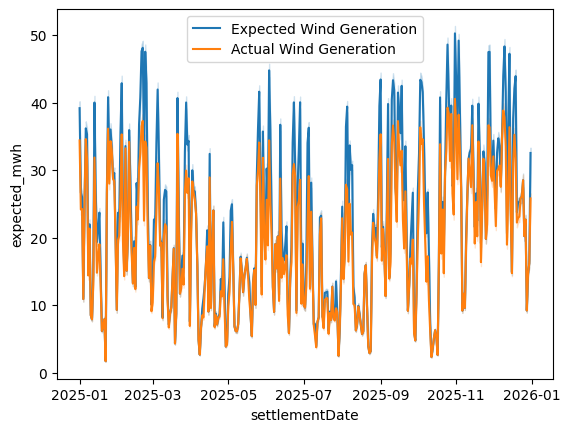

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

df['dayofyear'] = df['timeFrom'].dt.day_of_year

wind_df = df[df['action'] == 'Wind curtailed']

ax = sns.lineplot(data=wind_df, x='settlementDate',y='expected_mwh', label='Expected Wind Generation')
ax = sns.lineplot(data=wind_df, x='settlementDate',y='actual_mwh', label='Actual Wind Generation')

ax.legend()
plt.show()

In [22]:
grouped_cols = ['action','BmUnitId','settlementDate','longitude','latitude']
sum_cols = ['expected_mwh','actual_mwh','change_in_mwh','change_cost']

daily_df = df.groupby(grouped_cols)[sum_cols].sum().reset_index()
daily_df[daily_df['action'] == 'Wind curtailed'].sort_values('change_in_mwh',ascending=False)

,action,BmUnitId,settlementDate,longitude,latitude,expected_mwh,actual_mwh,change_in_mwh,change_cost
91827,Wind curtailed,SGRWO-6,2025-12-10,-1.965700,56.571500,8085.475,-1542.483333,9627.958333,144900.772917
91547,Wind curtailed,SGRWO-6,2025-03-05,-1.965700,56.571500,8549.350,-980.333333,9529.683333,3716.576500
91553,Wind curtailed,SGRWO-6,2025-03-11,-1.965700,56.571500,8069.500,-1377.508333,9447.008333,4062.213583
91484,Wind curtailed,SGRWO-6,2025-01-01,-1.965700,56.571500,8592.000,-666.600000,9258.600000,36571.470000
91490,Wind curtailed,SGRWO-6,2025-01-07,-1.965700,56.571500,8592.000,-666.600000,9258.600000,24231.199000
...,...,...,...,...,...,...,...,...,...
55891,Wind curtailed,FAARW-1,2025-02-07,-4.094167,57.325000,121.750,121.750000,0.000000,0.000000
55892,Wind curtailed,FAARW-1,2025-02-08,-4.094167,57.325000,29.500,29.500000,0.000000,0.000000
55893,Wind curtailed,FAARW-1,2025-02-09,-4.094167,57.325000,48.500,48.500000,0.000000,0.000000
55894,Wind curtailed,FAARW-1,2025-02-10,-4.094167,57.325000,258.750,258.750000,0.000000,0.000000


In [23]:
daily_df.to_csv('data/daily_data_v3.csv')

In [24]:
daily_df[daily_df['change_cost'] != 0].to_csv('data/daily_data_v3_trimmed.csv')

# Conclusions

- 10.9 TWh of wind generation was curtailed out of a potential 81.4 TWh, roughly a 13% reduction
- This cost the UK £375 million in direct payments for curtailing
- Curtailment occurred the most in June, September, and October